In [1]:
import pandas as pd

import sys
import os

os.chdir("../")

os.getcwd()

'c:\\Users\\ldiaz\\OneDrive\\Desktop\\CHE 4230\\meter_Hw4'

In [2]:
from src.data_preprocess import DataPreprocessing

preprocess = DataPreprocessing()

data = preprocess.load_data("data/Meter_A.txt")


         0         1         2         3          4          5         6   \
0  0.841499  1.009367  0.993816  8.469805  10.278727  10.037759  8.501365   
1  0.842250  1.006584  0.996605  7.531891   9.139924   8.951618  7.612213   
2  0.840723  1.011647  0.998152  6.641699   7.975464   7.857692  6.593117   
3  0.841119  1.017807  0.996812  5.687524   6.824334   6.689885  5.615428   
4  0.840358  1.016534  0.996221  5.660385   6.829560   6.675628  5.623977   

         7          8          9   ...         27         28         29  \
0  8.581726  10.247763  10.058822  ...  32.451173  34.568685  33.082683   
1  7.623325   9.106345   8.945142  ...  32.428385  34.441732  33.081055   
2  6.681572   7.964596   7.814698  ...  32.428385  34.275715  33.113605   
3  5.763315   6.801051   6.686639  ...  32.485350  34.080403  33.170573   
4  5.736818   6.813453   6.672377  ...  32.503255  34.122720  33.164062   

          30         31         32         33         34         35  36  
0  36.722005

c:\Users\ldiaz\anaconda3\envs\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


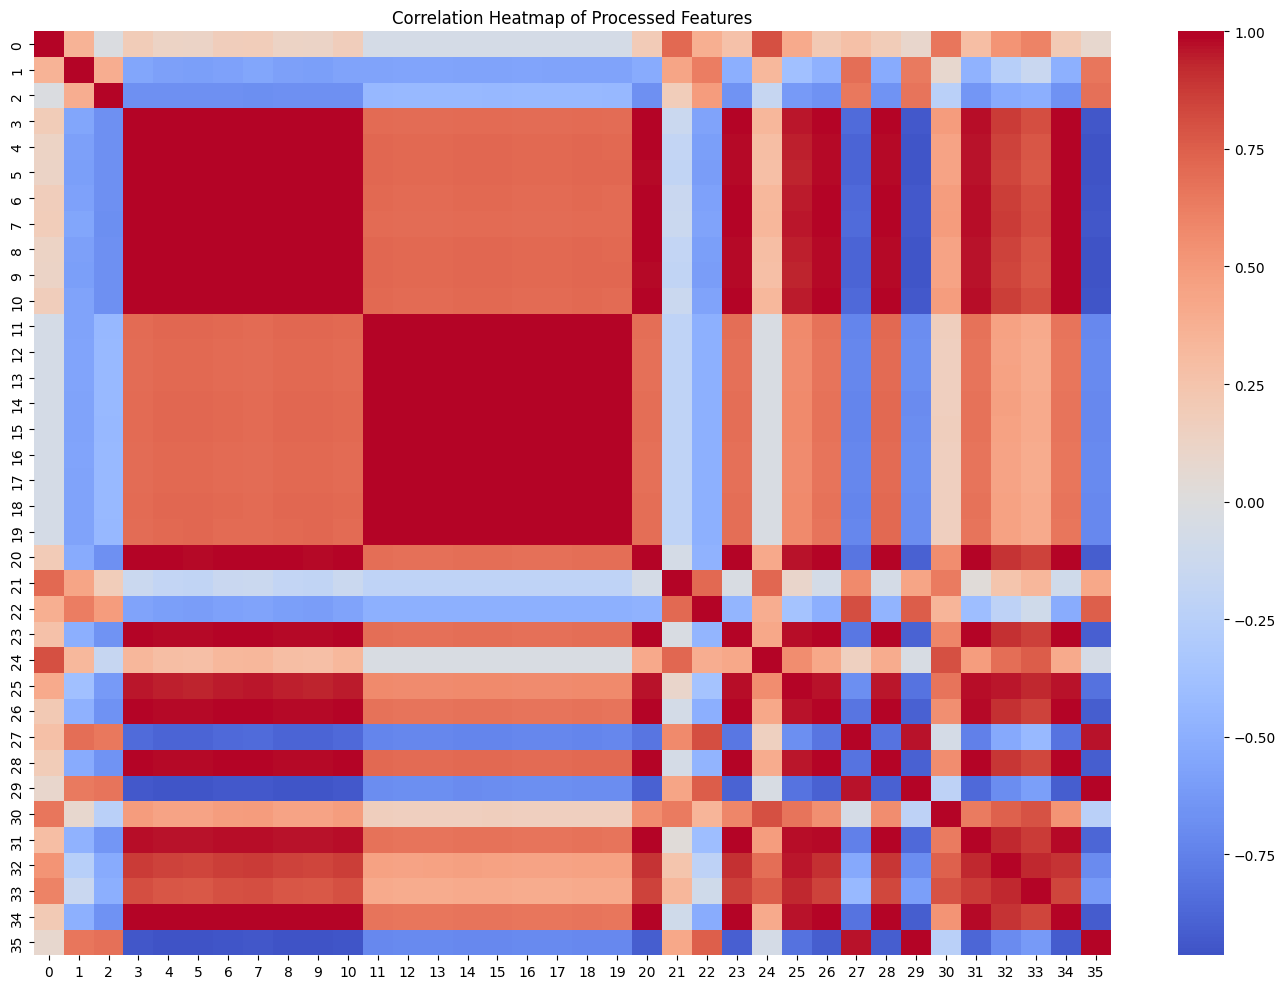

c:\Users\ldiaz\anaconda3\envs\myenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


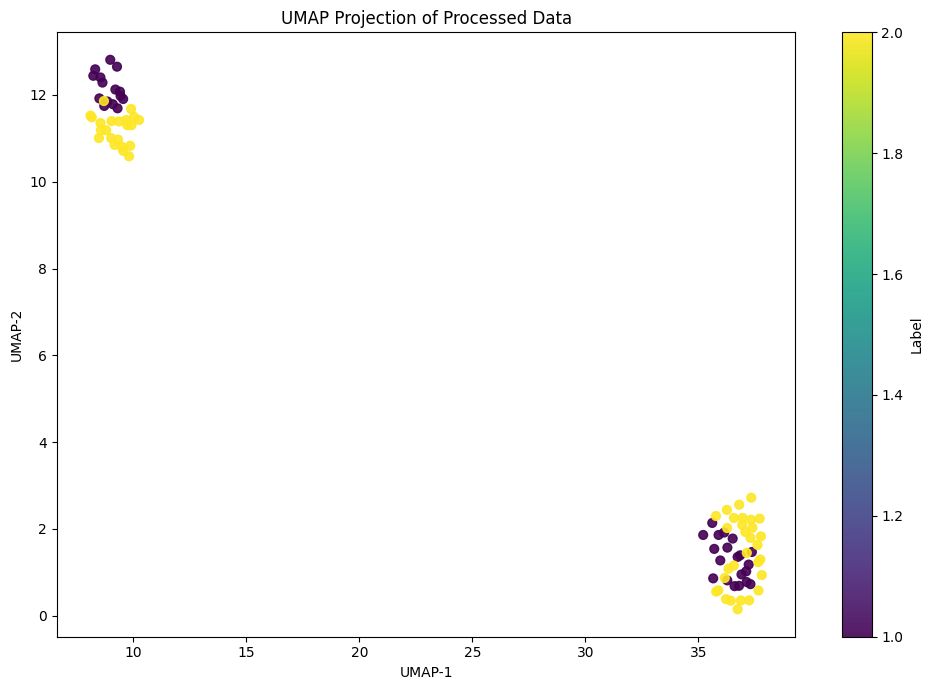

['X', 'X_scaled', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'data', 'plot_heatmap', 'plot_umap', 'scaler', 'y']


In [3]:
import sys
sys.path.append("..")
from src.preprocess_visualize import DataVisualizer

raw_data = data["raw_data"]   # from your preprocessing class

pre_viz = DataVisualizer(raw_data)

pre_viz.plot_heatmap()
pre_viz.plot_umap()
print(dir(pre_viz))


   Testing Model 1
   Config: {'hidden_layer_sizes': (45, 11), 'learning_rate_init': 0.0015, 'max_iter': 250}


c:\Users\ldiaz\anaconda3\envs\myenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (250) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.7777777777777778

Classification Report:
              precision    recall  f1-score   support

         1.0       0.73      0.89      0.80         9
         2.0       0.86      0.67      0.75         9

    accuracy                           0.78        18
   macro avg       0.79      0.78      0.78        18
weighted avg       0.79      0.78      0.77        18



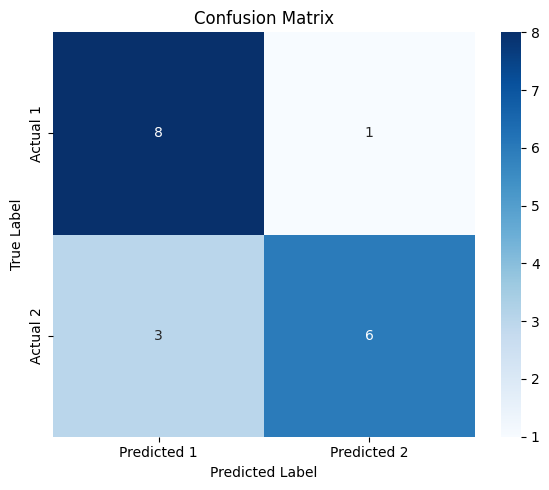

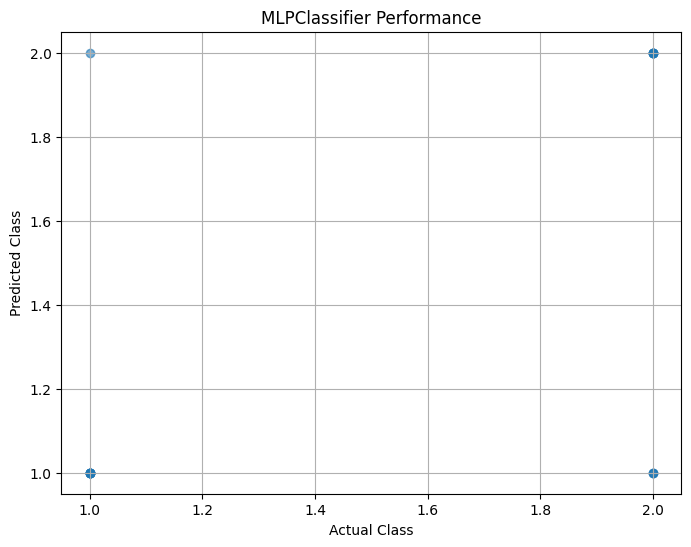


   Testing Model 2
   Config: {'hidden_layer_sizes': (84, 45), 'learning_rate_init': 0.0015, 'max_iter': 250}


c:\Users\ldiaz\anaconda3\envs\myenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (250) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.7777777777777778

Classification Report:
              precision    recall  f1-score   support

         1.0       0.86      0.67      0.75         9
         2.0       0.73      0.89      0.80         9

    accuracy                           0.78        18
   macro avg       0.79      0.78      0.78        18
weighted avg       0.79      0.78      0.77        18



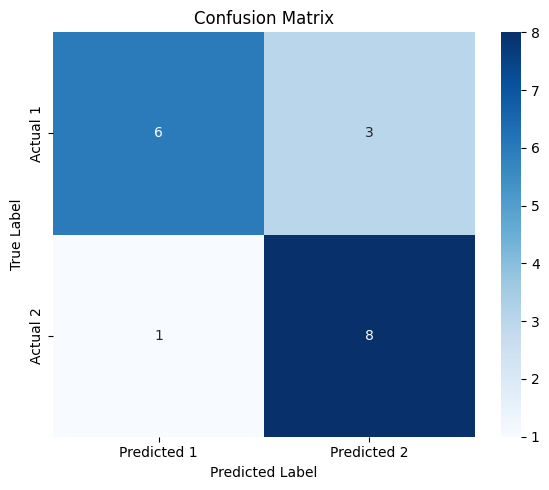

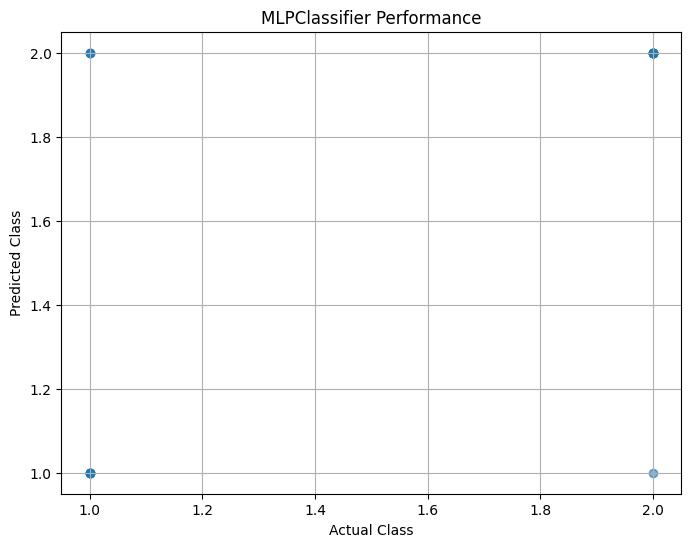


   Testing Model 3
   Config: {'hidden_layer_sizes': (84, 45), 'learning_rate_init': 0.0007, 'max_iter': 430}


c:\Users\ldiaz\anaconda3\envs\myenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (430) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.6666666666666666

Classification Report:
              precision    recall  f1-score   support

         1.0       0.71      0.56      0.62         9
         2.0       0.64      0.78      0.70         9

    accuracy                           0.67        18
   macro avg       0.68      0.67      0.66        18
weighted avg       0.68      0.67      0.66        18



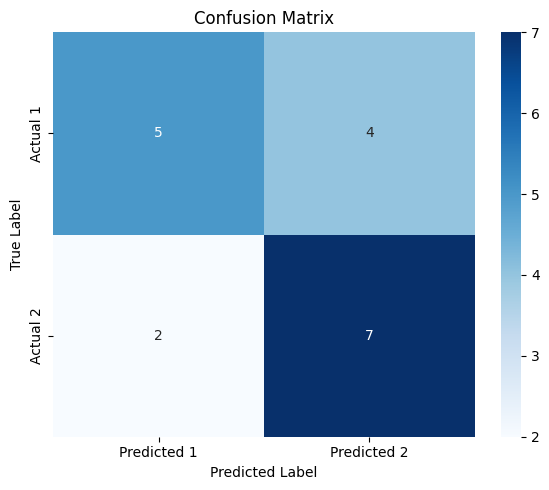

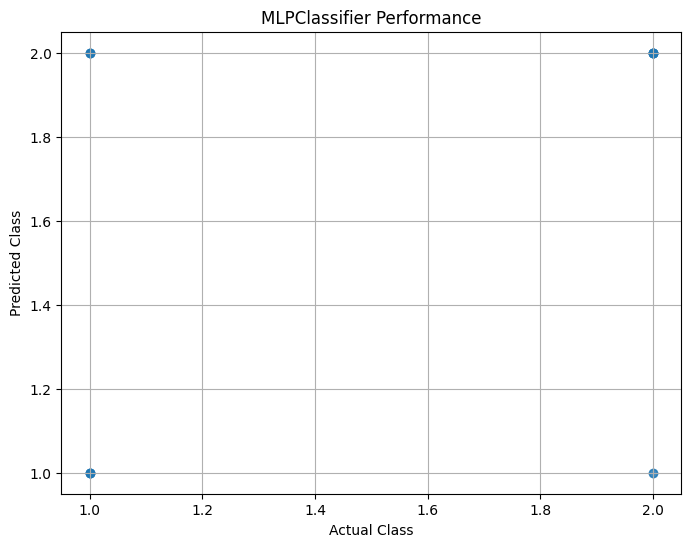


   Testing Model 4
   Config: {'hidden_layer_sizes': (128, 84), 'learning_rate_init': 0.0015, 'max_iter': 250}
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00         9
         2.0       1.00      1.00      1.00         9

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



c:\Users\ldiaz\anaconda3\envs\myenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (250) reached and the optimization hasn't converged yet.
  warnings.warn(


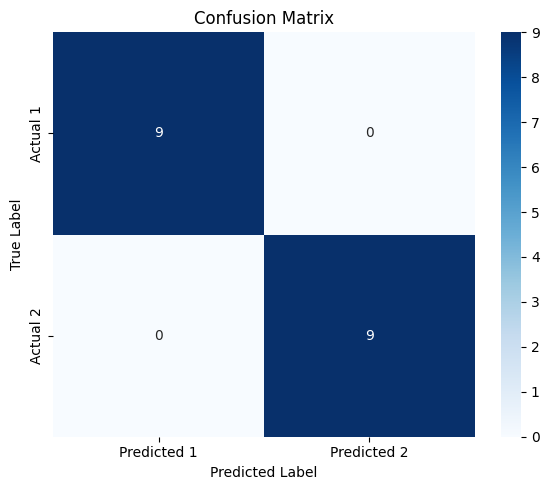

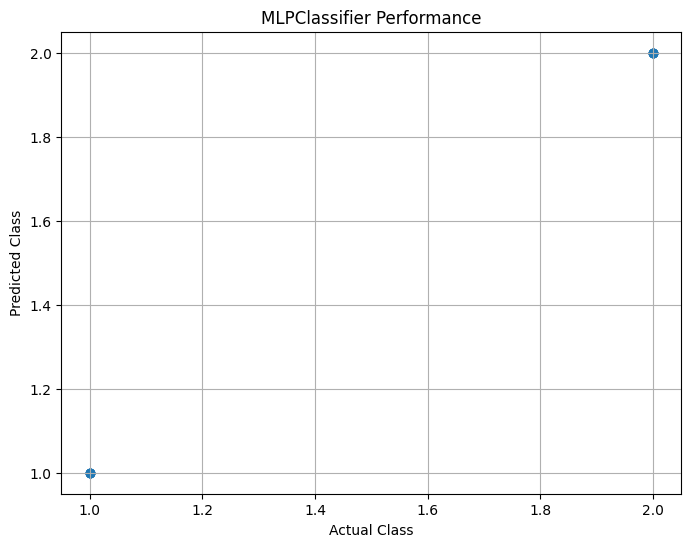

In [6]:
from src.mlpclassifier_test import MLPClassificationModel
from src.mlpclassifier_visualization import ConfusionMatrixVisualizer   # adjust if needed

# Extract data
X_train_scaled = data["X_train_scaled"]
y_train = data["y_train"]

X_test_scaled = data["X_test_scaled"]
y_test = data["y_test"]

# ---------------------------------------------------------
# Define 4 hyperparameter combinations to test
# ---------------------------------------------------------
configs = [
    {"hidden_layer_sizes": (45, 11), "learning_rate_init": 0.0015, "max_iter": 250},
    {"hidden_layer_sizes": (84, 45), "learning_rate_init": 0.0015, "max_iter": 250},
    {"hidden_layer_sizes": (84, 45), "learning_rate_init": 0.0007, "max_iter": 430},
    {"hidden_layer_sizes": (128, 84), "learning_rate_init": 0.0015, "max_iter": 250},
]

# ---------------------------------------------------------
# Loop through each configuration and evaluate + visualize
# ---------------------------------------------------------
for i, cfg in enumerate(configs, start=1):
    print(f"\n======================================")
    print(f"   Testing Model {i}")
    print(f"   Config: {cfg}")
    print(f"======================================")

    # Create model
    clf = MLPClassificationModel(
        hidden_layer_sizes=cfg["hidden_layer_sizes"],
        learning_rate_init=cfg["learning_rate_init"],
        max_iter=cfg["max_iter"]
    )

    # Train
    clf.train(X_train_scaled, y_train)

    # Evaluate
    y_pred = clf.evaluate(X_test_scaled, y_test)

    # Visualize
    viz = ConfusionMatrixVisualizer(y_test, y_pred)
    viz.plot_confusion_matrix()
    viz.plot_performance_scatter()


Model	Hidden Layers	Learning Rate	Iterations	Accuracy
Model 1	(45, 11)	    0.0015	            250	      77.8%
Model 2	(84, 45)	    0.0015	            250     	77.8%
Model 3	(84, 45)	    0.0007	            430	      66.7%
Model 4	(128, 84)	    0.0015	            250	       100%

Observations)

Model 4 performed the best, achieving perfect classification accuracy (100%).
Model 3 performed the worst.

Effect of Network Architecture)

Increasing network size improved performance:
Small network: (45,11) → 77.8%
Medium network: (84,45) → 77.8%
Large network: (128,84) → 100%

A larger neural network  resulted in improved classification performance.

A smaller learning rate reduced performance in this case.
The optimizer likely updated weights too slowly, leading to suboptimal convergence.

More iterations in Model 3 did not lead to a better result.

It is strange that Model 4 has perfect accuracy. Either I got lucky with th ehyperparameters, or an error was made. 

Shown in Test.ipynb is the MLPClassifier ANN using "adam" as a solver instead of "sgd". With "adam" I was getting the same answer for all iterations so the solver was changed. The first "adam" iteration had an accuracy of 94%. This suggests that in addition to changing hyperparamters, it is also worth looking into different solvers.

Matrix	Accuracy	Class 1 Recall	Class 2 Recall	Main Bias
1	77.8%	0.89	0.67	Predicts Class 1
2	77.8%	0.67	0.89	Predicts Class 2
3	66.7%	0.56	0.78	Weak overall

Its also interesting to see how the hyperparameter differences affect how good the model is at detection labels. The 1st iteraction is better at category 1 detection vs the matrix 2 & 3 which are better for Class 2. 

It is important to note that With such a small dataset: 1–2 misclassifications change accuracy significantly so results may vary due to random variation.